In [35]:
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260517_derived_membership_with_new_features.csv"
alpha = 0.05
min_significant_age_groups = 4
categorical_numeric_max_unique = 10

age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

binary_replace_map = {
    True: 1,
    False: 0,
    "true": 1,
    "false": 0,
    "y": 1,
    "n": 0,
    "yes": 1,
    "no": 0,
}

# CSV 로드
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 차이 검정
def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )

    return pvalue

# 이진형 정규화
def normalize_binary_series(series):
    temp = series.dropna().copy()

    if len(temp) == 0:
        return pd.Series(dtype="int64")

    if pd.api.types.is_object_dtype(temp) or pd.api.types.is_string_dtype(temp):
        temp = temp.astype(str).str.strip().str.lower()

    temp = temp.replace(binary_replace_map)
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]

    return temp.astype(int)

# 이진형 판별
def is_binary_feature(series):
    temp = series.dropna().copy()

    if len(temp) == 0:
        return False

    if pd.api.types.is_object_dtype(temp) or pd.api.types.is_string_dtype(temp):
        temp = temp.astype(str).str.strip().str.lower()

    temp = temp.replace(binary_replace_map)
    temp = pd.to_numeric(temp, errors="coerce")

    if temp.isna().any():
        return False

    return set(temp.unique()).issubset({0, 1})

# 피처 타입 추론
def infer_feature_type(series):
    non_null = series.dropna()

    if len(non_null) == 0:
        return "skip"

    if is_binary_feature(non_null):
        return "binary"

    numeric = pd.to_numeric(non_null, errors="coerce")

    if numeric.notna().all():
        unique_count = numeric.nunique()
        integer_like_flag = np.all(np.isclose(numeric % 1, 0))

        if unique_count <= categorical_numeric_max_unique and integer_like_flag:
            return "categorical"

        return "numeric"

    return "categorical"

# 이진형 검정
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    return run_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )

# 범주형 검정
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(contingency.values, alternative="two-sided")
            return fisher_pvalue

        return chi2_pvalue

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue

# 수치형 검정
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue

# 피처별 p-value 계산
def get_feature_pvalue(df0_age, df1_age, feature_name, feature_type_map):
    feature_type = feature_type_map[feature_name]

    if feature_type == "binary":
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_type == "categorical":
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_type == "numeric":
        return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

    return np.nan

# 데이터 준비
df = read_membership_csv(file_path)
df = preprocess(df)

df0 = df[df["is_promotion"] == 0].copy()
df1 = df[df["is_promotion"] == 1].copy()

# age_group별 이탈률 집계
g0 = (
    df0.groupby("age_group", observed=True)["churn"]
    .agg(churn_0="sum", total_0="count")
    .reset_index()
)

g1 = (
    df1.groupby("age_group", observed=True)["churn"]
    .agg(churn_1="sum", total_1="count")
    .reset_index()
)

merged = pd.merge(g0, g1, on="age_group", how="inner")

merged["age_group"] = pd.Categorical(
    merged["age_group"],
    categories=age_labels,
    ordered=True
)
merged = merged.sort_values("age_group").reset_index(drop=True)

# 유의한 age_group 추출
significant_age_groups = []

for _, row in merged.iterrows():
    churn_0 = int(row["churn_0"])
    total_0 = int(row["total_0"])
    churn_1 = int(row["churn_1"])
    total_1 = int(row["total_1"])

    if total_0 == 0 or total_1 == 0:
        continue

    pvalue = run_test(churn_0, total_0, churn_1, total_1)

    if pd.notna(pvalue) and pvalue < alpha:
        significant_age_groups.append(str(row["age_group"]))

# 후보 피처 선정
candidate_features = [
    col for col in df.columns
    if col not in exclude_features
]

feature_type_map = {
    feature_name: infer_feature_type(df[feature_name])
    for feature_name in candidate_features
}

# age_group별 피처 차이 검정
significant_age_groups_by_feature = defaultdict(list)

for age_group in significant_age_groups:
    df0_age = df0[df0["age_group"].astype(str) == age_group].copy()
    df1_age = df1[df1["age_group"].astype(str) == age_group].copy()

    if len(df0_age) == 0 or len(df1_age) == 0:
        continue

    for feature_name in candidate_features:
        pvalue = get_feature_pvalue(df0_age, df1_age, feature_name, feature_type_map)

        if pd.notna(pvalue) and pvalue < alpha:
            significant_age_groups_by_feature[feature_name].append(age_group)

# 결과 정리
feature_summary = []

for feature_name in candidate_features:
    matched_age_groups = [
        age_group for age_group in age_labels
        if age_group in significant_age_groups_by_feature[feature_name]
    ]

    if len(matched_age_groups) >= min_significant_age_groups:
        feature_summary.append(
            (feature_name, len(matched_age_groups), matched_age_groups)
        )

feature_summary.sort(key=lambda x: (-x[1], x[0]))

# 결과 출력
if not feature_summary:
    print("없음")
else:
    grouped_result = defaultdict(list)

    for feature_name, matched_count, matched_age_groups in feature_summary:
        grouped_result[matched_count].append((feature_name, matched_age_groups))

    for matched_count in sorted(grouped_result.keys(), reverse=True):
        print(f"[{matched_count}개 age_group 유의]")
        for feature_name, matched_age_groups in grouped_result[matched_count]:
            print(f"{feature_name} : {', '.join(matched_age_groups)}")


[5개 age_group 유의]
gap_resilient_value_score : 10대, 20대, 30대, 40대, 60대
is_churn_prevented : 10대, 20대, 30대, 40대, 60대
is_premium : 10대, 20대, 30대, 40대, 60대
is_user_verified : 10대, 20대, 30대, 40대, 60대
max_screen : 10대, 20대, 30대, 40대, 60대
payment_device : 10대, 20대, 30대, 40대, 60대
payment_is_ios : 10대, 20대, 30대, 40대, 60대
payment_is_mobile : 10대, 20대, 30대, 40대, 60대
payment_is_pc : 10대, 20대, 30대, 40대, 60대
product_code : 10대, 20대, 30대, 40대, 60대
recency_adjusted_value_score : 10대, 20대, 30대, 40대, 60대
reg_hour_morning : 10대, 20대, 30대, 40대, 60대
screen_value_efficiency : 10대, 20대, 30대, 40대, 60대
verified_watch_value_weighted : 10대, 20대, 30대, 40대, 60대
[4개 age_group 유의]
gender : 20대, 30대, 40대, 60대
is_male : 20대, 30대, 40대, 60대
is_standard : 20대, 30대, 40대, 60대
price : 10대, 20대, 30대, 60대
reg_hour_evening : 10대, 20대, 30대, 40대
verified_multiscreen_depth_weighted : 10대, 20대, 30대, 40대


In [36]:
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260517_derived_membership_with_new_features.csv"
alpha = 0.05
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 정의
def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

df0 = membership[membership["is_promotion"] == 0].copy()
df1 = membership[membership["is_promotion"] == 1].copy()

g0 = (
    df0.groupby("age_group", observed=True)["churn"]
    .agg(churn_0="sum", total_0="count")
    .reset_index()
)

g1 = (
    df1.groupby("age_group", observed=True)["churn"]
    .agg(churn_1="sum", total_1="count")
    .reset_index()
)

merged = pd.merge(g0, g1, on="age_group", how="inner")

merged["age_group"] = pd.Categorical(
    merged["age_group"],
    categories=age_labels,
    ordered=True
)
merged = merged.sort_values("age_group").reset_index(drop=True)

significant_age_groups = []

for _, row in merged.iterrows():
    churn_0 = int(row["churn_0"])
    total_0 = int(row["total_0"])
    churn_1 = int(row["churn_1"])
    total_1 = int(row["total_1"])

    if total_0 == 0 or total_1 == 0:
        continue

    pvalue, _ = run_test(churn_0, total_0, churn_1, total_1)

    if pvalue < alpha:
        significant_age_groups.append(str(row["age_group"]))

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

candidate_features = [
    col for col in df0.columns
    if col in df1.columns and col not in exclude_features
]

# 이진형 정규화 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    pvalue, _ = run_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue

# 범주형 검정 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    combined = pd.concat([s0, s1], ignore_index=True)
    if combined.nunique() <= 1:
        return 1.0

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)
        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(contingency.values, alternative="two-sided")
            return fisher_pvalue
        return chi2_pvalue

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue

# 수치형 검정 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue

# 피처별 p-value 계산 정의
def get_feature_pvalue(df0_age, df1_age, feature_name):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

significant_age_groups_by_feature = defaultdict(list)

for age_group in significant_age_groups:
    df0_age = df0[df0["age_group"].astype(str) == age_group].copy()
    df1_age = df1[df1["age_group"].astype(str) == age_group].copy()

    if len(df0_age) == 0 or len(df1_age) == 0:
        continue

    for feature_name in candidate_features:
        pvalue = get_feature_pvalue(df0_age, df1_age, feature_name)

        if pd.notna(pvalue) and pvalue < alpha:
            significant_age_groups_by_feature[feature_name].append(age_group)

grouped_results = defaultdict(list)

for feature_name in candidate_features:
    matched_age_groups = [
        age_group for age_group in age_labels
        if age_group in significant_age_groups_by_feature[feature_name]
    ]

    if len(matched_age_groups) >= 3:
        grouped_results[len(matched_age_groups)].append(
            (feature_name, matched_age_groups)
        )

if not grouped_results:
    print("없음")
else:
    sorted_group_counts = sorted(grouped_results.keys(), reverse=True)

    for idx, group_count in enumerate(sorted_group_counts):
        if idx > 0:
            print()

        print(f"[{group_count}개 age_group 유의]")

        for feature_name, matched_age_groups in sorted(grouped_results[group_count]):
            print(f"{feature_name} : {', '.join(matched_age_groups)}")


[5개 age_group 유의]
gap_resilient_value_score : 10대, 20대, 30대, 40대, 60대
is_churn_prevented : 10대, 20대, 30대, 40대, 60대
is_premium : 10대, 20대, 30대, 40대, 60대
is_user_verified : 10대, 20대, 30대, 40대, 60대
max_screen : 10대, 20대, 30대, 40대, 60대
payment_device : 10대, 20대, 30대, 40대, 60대
payment_is_ios : 10대, 20대, 30대, 40대, 60대
payment_is_mobile : 10대, 20대, 30대, 40대, 60대
payment_is_pc : 10대, 20대, 30대, 40대, 60대
product_code : 10대, 20대, 30대, 40대, 60대
recency_adjusted_value_score : 10대, 20대, 30대, 40대, 60대
reg_hour_morning : 10대, 20대, 30대, 40대, 60대
screen_value_efficiency : 10대, 20대, 30대, 40대, 60대
verified_watch_value_weighted : 10대, 20대, 30대, 40대, 60대

[4개 age_group 유의]
gender : 20대, 30대, 40대, 60대
is_male : 20대, 30대, 40대, 60대
is_standard : 20대, 30대, 40대, 60대
price : 10대, 20대, 30대, 60대
reg_hour_evening : 10대, 20대, 30대, 40대
verified_multiscreen_depth_weighted : 10대, 20대, 30대, 40대

[3개 age_group 유의]
is_female : 20대, 40대, 60대
mobile_commitment_efficiency : 20대, 30대, 40대
payment_is_android : 20대, 40대, 60대
pre

In [37]:
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260517_derived_membership_with_new_features.csv"
alpha = 0.05
min_age_group_count = 2
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 함수 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 함수 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 함수 정의
def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

# 프로모션 그룹 분리
df0 = membership[membership["is_promotion"] == 0].copy()
df1 = membership[membership["is_promotion"] == 1].copy()

# age_group별 이탈자 수 집계
g0 = (
    df0.groupby("age_group", observed=True)["churn"]
    .agg(churn_0="sum", total_0="count")
    .reset_index()
)

g1 = (
    df1.groupby("age_group", observed=True)["churn"]
    .agg(churn_1="sum", total_1="count")
    .reset_index()
)

merged = pd.merge(g0, g1, on="age_group", how="inner")

merged["age_group"] = pd.Categorical(
    merged["age_group"],
    categories=age_labels,
    ordered=True
)
merged = merged.sort_values("age_group").reset_index(drop=True)

# 이탈률 차이 유의 age_group 추출
significant_age_groups = []

for _, row in merged.iterrows():
    churn_0 = int(row["churn_0"])
    total_0 = int(row["total_0"])
    churn_1 = int(row["churn_1"])
    total_1 = int(row["total_1"])

    if total_0 == 0 or total_1 == 0:
        continue

    pvalue, _ = run_test(churn_0, total_0, churn_1, total_1)

    if pvalue < alpha:
        significant_age_groups.append(str(row["age_group"]))

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

candidate_features = [
    col for col in df0.columns
    if col in df1.columns and col not in exclude_features
]

# 이진형 정규화 함수 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 함수 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    pvalue, _ = run_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue

# 범주형 검정 함수 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(
                contingency.values,
                alternative="two-sided"
            )
            return fisher_pvalue

        return chi2_pvalue

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue

# 수치형 검정 함수 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue

# 피처별 p-value 계산 함수 정의
def get_feature_pvalue(df0_age, df1_age, feature_name):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

# age_group별 유의 결과 저장
significant_age_groups_by_feature = defaultdict(list)

for age_group in significant_age_groups:
    df0_age = df0[df0["age_group"].astype(str) == age_group].copy()
    df1_age = df1[df1["age_group"].astype(str) == age_group].copy()

    if len(df0_age) == 0 or len(df1_age) == 0:
        continue

    for feature_name in candidate_features:
        pvalue = get_feature_pvalue(df0_age, df1_age, feature_name)

        if pd.notna(pvalue) and pvalue < alpha:
            significant_age_groups_by_feature[feature_name].append(age_group)

# 출력용 결과 정리
grouped_results = defaultdict(list)

for feature_name in candidate_features:
    matched_age_groups = [
        age_group for age_group in age_labels
        if age_group in significant_age_groups_by_feature[feature_name]
    ]

    if len(matched_age_groups) >= min_age_group_count:
        grouped_results[len(matched_age_groups)].append(
            (feature_name, matched_age_groups)
        )

# 결과 출력
if not grouped_results:
    print("없음")
else:
    sorted_group_counts = sorted(grouped_results.keys(), reverse=True)

    for idx, group_count in enumerate(sorted_group_counts):
        if idx > 0:
            print()

        print(f"[{group_count}개 age_group 유의]")

        for feature_name, matched_age_groups in sorted(grouped_results[group_count]):
            print(f"{feature_name} : {', '.join(matched_age_groups)}")


[5개 age_group 유의]
gap_resilient_value_score : 10대, 20대, 30대, 40대, 60대
is_churn_prevented : 10대, 20대, 30대, 40대, 60대
is_premium : 10대, 20대, 30대, 40대, 60대
is_user_verified : 10대, 20대, 30대, 40대, 60대
max_screen : 10대, 20대, 30대, 40대, 60대
payment_device : 10대, 20대, 30대, 40대, 60대
payment_is_ios : 10대, 20대, 30대, 40대, 60대
payment_is_mobile : 10대, 20대, 30대, 40대, 60대
payment_is_pc : 10대, 20대, 30대, 40대, 60대
product_code : 10대, 20대, 30대, 40대, 60대
recency_adjusted_value_score : 10대, 20대, 30대, 40대, 60대
reg_hour_morning : 10대, 20대, 30대, 40대, 60대
screen_value_efficiency : 10대, 20대, 30대, 40대, 60대
verified_watch_value_weighted : 10대, 20대, 30대, 40대, 60대

[4개 age_group 유의]
gender : 20대, 30대, 40대, 60대
is_male : 20대, 30대, 40대, 60대
is_standard : 20대, 30대, 40대, 60대
price : 10대, 20대, 30대, 60대
reg_hour_evening : 10대, 20대, 30대, 40대
verified_multiscreen_depth_weighted : 10대, 20대, 30대, 40대

[3개 age_group 유의]
is_female : 20대, 40대, 60대
mobile_commitment_efficiency : 20대, 30대, 40대
payment_is_android : 20대, 40대, 60대
pre

## 10대

In [38]:
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260517_derived_membership_with_new_features.csv"
alpha = 0.05
target_age_group = "10대"
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 함수 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 함수 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 함수 정의
def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

# 이진형 정규화 함수 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 함수 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Binary test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    pvalue, test_name = run_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue, test_name

# 범주형 검정 함수 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Categorical test skipped"

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0, "No variation"

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0, "No variation"

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(
                contingency.values,
                alternative="two-sided"
            )
            return fisher_pvalue, "Fisher exact test"

        return chi2_pvalue, "Chi-square test"

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue, "Chi-square test"

# 수치형 검정 함수 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Numeric test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue, "Mann-Whitney U test"

# 피처별 검정 함수 정의
def get_feature_test_result(df0_age, df1_age, feature_name, binary_features, categorical_features):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

# 대상 나이대 필터링
target_df = membership[membership["age_group"].astype(str) == target_age_group].copy()

# 프로모션 그룹 분리
df0_age = target_df[target_df["is_promotion"] == 0].copy()
df1_age = target_df[target_df["is_promotion"] == 1].copy()

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

candidate_features = [
    col for col in df0_age.columns
    if col in df1_age.columns and col not in exclude_features
]

# 유의 컬럼 추출
significant_results = []

for feature_name in candidate_features:
    pvalue, test_name = get_feature_test_result(
        df0_age,
        df1_age,
        feature_name,
        binary_features,
        categorical_features
    )

    if pd.notna(pvalue) and pvalue < alpha:
        significant_results.append(
            {
                "feature_name": feature_name,
                "pvalue": pvalue,
                "test_name": test_name,
            }
        )

# 결과 출력
if len(df0_age) == 0 or len(df1_age) == 0:
    print("없음")
elif not significant_results:
    print("없음")
else:
    result_df = pd.DataFrame(significant_results)
    result_df = result_df.sort_values(
        by=["pvalue", "feature_name"],
        ascending=[True, True]
    ).reset_index(drop=True)

    print(f"[{target_age_group} 유의 컬럼]")
    print(f"총 {len(result_df)}개")

    for _, row in result_df.iterrows():
        print(
            f"{row['feature_name']} | "
            f"p-value={row['pvalue']:.6g} | "
            f"검정법={row['test_name']}"
        )


[10대 유의 컬럼]
총 19개
price | p-value=2.90246e-48 | 검정법=Mann-Whitney U test
gap_resilient_value_score | p-value=2.80828e-23 | 검정법=Mann-Whitney U test
verified_watch_value_weighted | p-value=6.28614e-22 | 검정법=Mann-Whitney U test
recency_adjusted_value_score | p-value=1.03652e-20 | 검정법=Mann-Whitney U test
screen_value_efficiency | p-value=1.0779e-20 | 검정법=Mann-Whitney U test
reg_hour_morning | p-value=1.38667e-15 | 검정법=Mann-Whitney U test
payment_device | p-value=4.34839e-13 | 검정법=Chi-square test
payment_is_ios | p-value=3.49356e-12 | 검정법=Mann-Whitney U test
product_code | p-value=4.002e-11 | 검정법=Chi-square test
is_churn_prevented | p-value=3.06145e-08 | 검정법=Two-proportion z-test
is_user_verified | p-value=1.48084e-07 | 검정법=Fisher exact test
is_premium | p-value=0.000236704 | 검정법=Mann-Whitney U test
reg_is_weekend | p-value=0.000398584 | 검정법=Mann-Whitney U test
reg_hour_evening | p-value=0.000752448 | 검정법=Mann-Whitney U test
max_screen | p-value=0.000767349 | 검정법=Chi-square test
payment_is_p

## 20대

In [39]:
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260517_derived_membership_with_new_features.csv"
alpha = 0.05
target_age_group = "20대"
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 함수 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 함수 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 함수 정의
def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

# 이진형 정규화 함수 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 함수 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Binary test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    pvalue, test_name = run_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue, test_name

# 범주형 검정 함수 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Categorical test skipped"

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0, "No variation"

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0, "No variation"

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(
                contingency.values,
                alternative="two-sided"
            )
            return fisher_pvalue, "Fisher exact test"

        return chi2_pvalue, "Chi-square test"

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue, "Chi-square test"

# 수치형 검정 함수 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Numeric test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue, "Mann-Whitney U test"

# 피처별 검정 함수 정의
def get_feature_test_result(df0_age, df1_age, feature_name, binary_features, categorical_features):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

# 대상 나이대 필터링
target_df = membership[membership["age_group"].astype(str) == target_age_group].copy()

# 프로모션 그룹 분리
df0_age = target_df[target_df["is_promotion"] == 0].copy()
df1_age = target_df[target_df["is_promotion"] == 1].copy()

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

candidate_features = [
    col for col in df0_age.columns
    if col in df1_age.columns and col not in exclude_features
]

# 유의 컬럼 추출
significant_results = []

for feature_name in candidate_features:
    pvalue, test_name = get_feature_test_result(
        df0_age,
        df1_age,
        feature_name,
        binary_features,
        categorical_features
    )

    if pd.notna(pvalue) and pvalue < alpha:
        significant_results.append(
            {
                "feature_name": feature_name,
                "pvalue": pvalue,
                "test_name": test_name,
            }
        )

# 결과 출력
if len(df0_age) == 0 or len(df1_age) == 0:
    print("없음")
elif not significant_results:
    print("없음")
else:
    result_df = pd.DataFrame(significant_results)
    result_df = result_df.sort_values(
        by=["pvalue", "feature_name"],
        ascending=[True, True]
    ).reset_index(drop=True)

    print(f"[{target_age_group} 유의 컬럼]")
    print(f"총 {len(result_df)}개")

    for _, row in result_df.iterrows():
        print(
            f"{row['feature_name']} | "
            f"p-value={row['pvalue']:.6g} | "
            f"검정법={row['test_name']}"
        )


[20대 유의 컬럼]
총 33개
payment_device | p-value=0 | 검정법=Chi-square test
price | p-value=0 | 검정법=Mann-Whitney U test
product_code | p-value=5.01904e-307 | 검정법=Chi-square test
payment_is_ios | p-value=1.66175e-266 | 검정법=Mann-Whitney U test
gap_resilient_value_score | p-value=1.37066e-252 | 검정법=Mann-Whitney U test
verified_watch_value_weighted | p-value=2.98545e-232 | 검정법=Mann-Whitney U test
recency_adjusted_value_score | p-value=8.96796e-231 | 검정법=Mann-Whitney U test
screen_value_efficiency | p-value=1.62532e-221 | 검정법=Mann-Whitney U test
is_user_verified | p-value=1.77264e-115 | 검정법=Fisher exact test
max_screen | p-value=2.52297e-67 | 검정법=Chi-square test
payment_is_mobile | p-value=1.81589e-63 | 검정법=Mann-Whitney U test
is_premium | p-value=8.01992e-58 | 검정법=Mann-Whitney U test
reg_hour_morning | p-value=2.43847e-52 | 검정법=Mann-Whitney U test
is_churn_prevented | p-value=5.8934e-50 | 검정법=Two-proportion z-test
gender | p-value=1.18865e-34 | 검정법=Chi-square test
is_standard | p-value=2.97483e-27 

## 30대

In [40]:
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260517_derived_membership_with_new_features.csv"
alpha = 0.05
target_age_group = "30대"
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 함수 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 함수 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 함수 정의
def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

# 이진형 정규화 함수 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 함수 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Binary test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    pvalue, test_name = run_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue, test_name

# 범주형 검정 함수 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Categorical test skipped"

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0, "No variation"

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0, "No variation"

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(
                contingency.values,
                alternative="two-sided"
            )
            return fisher_pvalue, "Fisher exact test"

        return chi2_pvalue, "Chi-square test"

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue, "Chi-square test"

# 수치형 검정 함수 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Numeric test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue, "Mann-Whitney U test"

# 피처별 검정 함수 정의
def get_feature_test_result(df0_age, df1_age, feature_name, binary_features, categorical_features):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

# 대상 나이대 필터링
target_df = membership[membership["age_group"].astype(str) == target_age_group].copy()

# 프로모션 그룹 분리
df0_age = target_df[target_df["is_promotion"] == 0].copy()
df1_age = target_df[target_df["is_promotion"] == 1].copy()

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

candidate_features = [
    col for col in df0_age.columns
    if col in df1_age.columns and col not in exclude_features
]

# 유의 컬럼 추출
significant_results = []

for feature_name in candidate_features:
    pvalue, test_name = get_feature_test_result(
        df0_age,
        df1_age,
        feature_name,
        binary_features,
        categorical_features
    )

    if pd.notna(pvalue) and pvalue < alpha:
        significant_results.append(
            {
                "feature_name": feature_name,
                "pvalue": pvalue,
                "test_name": test_name,
            }
        )

# 결과 출력
if len(df0_age) == 0 or len(df1_age) == 0:
    print("없음")
elif not significant_results:
    print("없음")
else:
    result_df = pd.DataFrame(significant_results)
    result_df = result_df.sort_values(
        by=["pvalue", "feature_name"],
        ascending=[True, True]
    ).reset_index(drop=True)

    print(f"[{target_age_group} 유의 컬럼]")
    print(f"총 {len(result_df)}개")

    for _, row in result_df.iterrows():
        print(
            f"{row['feature_name']} | "
            f"p-value={row['pvalue']:.6g} | "
            f"검정법={row['test_name']}"
        )


[30대 유의 컬럼]
총 25개
gap_resilient_value_score | p-value=0 | 검정법=Mann-Whitney U test
price | p-value=0 | 검정법=Mann-Whitney U test
screen_value_efficiency | p-value=0 | 검정법=Mann-Whitney U test
verified_watch_value_weighted | p-value=0 | 검정법=Mann-Whitney U test
recency_adjusted_value_score | p-value=1.31523e-303 | 검정법=Mann-Whitney U test
payment_device | p-value=2.40548e-153 | 검정법=Chi-square test
product_code | p-value=4.20324e-144 | 검정법=Chi-square test
payment_is_ios | p-value=3.27662e-125 | 검정법=Mann-Whitney U test
is_user_verified | p-value=4.96099e-107 | 검정법=Fisher exact test
payment_is_mobile | p-value=3.7663e-33 | 검정법=Mann-Whitney U test
max_screen | p-value=3.19752e-31 | 검정법=Chi-square test
is_churn_prevented | p-value=1.41437e-27 | 검정법=Two-proportion z-test
reg_hour_morning | p-value=1.53883e-25 | 검정법=Mann-Whitney U test
is_standard | p-value=1.40279e-21 | 검정법=Mann-Whitney U test
is_premium | p-value=4.08702e-20 | 검정법=Mann-Whitney U test
gender | p-value=1.16958e-18 | 검정법=Chi-square t

## 40대

In [41]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260517_derived_membership_with_new_features.csv"
alpha = 0.05
target_age_group = "40대"
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 함수 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 함수 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 함수 정의
def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

# 이진형 정규화 함수 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 함수 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Binary test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    pvalue, test_name = run_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue, test_name

# 범주형 검정 함수 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Categorical test skipped"

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0, "No variation"

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0, "No variation"

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(
                contingency.values,
                alternative="two-sided"
            )
            return fisher_pvalue, "Fisher exact test"

        return chi2_pvalue, "Chi-square test"

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue, "Chi-square test"

# 수치형 검정 함수 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Numeric test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue, "Mann-Whitney U test"

# 피처별 검정 함수 정의
def get_feature_test_result(df0_age, df1_age, feature_name, binary_features, categorical_features):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

# 대상 나이대 필터링
target_df = membership[membership["age_group"].astype(str) == target_age_group].copy()

# 프로모션 그룹 분리
df0_age = target_df[target_df["is_promotion"] == 0].copy()
df1_age = target_df[target_df["is_promotion"] == 1].copy()

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

candidate_features = [
    col for col in df0_age.columns
    if col in df1_age.columns and col not in exclude_features
]

# 유의 컬럼 추출
significant_results = []

for feature_name in candidate_features:
    pvalue, test_name = get_feature_test_result(
        df0_age,
        df1_age,
        feature_name,
        binary_features,
        categorical_features
    )

    if pd.notna(pvalue) and pvalue < alpha:
        significant_results.append(
            {
                "feature_name": feature_name,
                "pvalue": pvalue,
                "test_name": test_name,
            }
        )

# 결과 출력
if len(df0_age) == 0 or len(df1_age) == 0:
    print("없음")
elif not significant_results:
    print("없음")
else:
    result_df = pd.DataFrame(significant_results)
    result_df = result_df.sort_values(
        by=["pvalue", "feature_name"],
        ascending=[True, True]
    ).reset_index(drop=True)

    print(f"[{target_age_group} 유의 컬럼]")
    print(f"총 {len(result_df)}개")

    for _, row in result_df.iterrows():
        print(
            f"{row['feature_name']} | "
            f"p-value={row['pvalue']:.6g} | "
            f"검정법={row['test_name']}"
        )


[40대 유의 컬럼]
총 28개
gender | p-value=0 | 검정법=Chi-square test
is_user_verified | p-value=0 | 검정법=Fisher exact test
payment_device | p-value=0 | 검정법=Chi-square test
payment_is_ios | p-value=0 | 검정법=Mann-Whitney U test
product_code | p-value=0 | 검정법=Chi-square test
age | p-value=2.9412e-288 | 검정법=Mann-Whitney U test
payment_is_android | p-value=3.45727e-202 | 검정법=Mann-Whitney U test
verified_multiscreen_depth_weighted | p-value=2.57486e-169 | 검정법=Mann-Whitney U test
is_female | p-value=1.25019e-141 | 검정법=Mann-Whitney U test
is_male | p-value=9.74541e-137 | 검정법=Mann-Whitney U test
verified_watch_value_weighted | p-value=1.21408e-27 | 검정법=Mann-Whitney U test
recency_adjusted_value_score | p-value=3.36687e-23 | 검정법=Mann-Whitney U test
payment_is_pc | p-value=1.93568e-20 | 검정법=Mann-Whitney U test
max_screen | p-value=2.63106e-15 | 검정법=Chi-square test
is_premium | p-value=3.11601e-15 | 검정법=Mann-Whitney U test
gap_resilient_value_score | p-value=5.28579e-15 | 검정법=Mann-Whitney U test
screen_value_

## 60대

In [42]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260517_derived_membership_with_new_features.csv"
alpha = 0.05
target_age_group = "60대"
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 함수 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 함수 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 함수 정의
def run_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
        test_name = "Fisher exact test"
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )
        test_name = "Two-proportion z-test"

    return pvalue, test_name

# 이진형 정규화 함수 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 함수 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Binary test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    pvalue, test_name = run_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue, test_name

# 범주형 검정 함수 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Categorical test skipped"

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0, "No variation"

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0, "No variation"

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(
                contingency.values,
                alternative="two-sided"
            )
            return fisher_pvalue, "Fisher exact test"

        return chi2_pvalue, "Chi-square test"

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue, "Chi-square test"

# 수치형 검정 함수 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan, "Numeric test skipped"

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0, "No variation"

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue, "Mann-Whitney U test"

# 피처별 검정 함수 정의
def get_feature_test_result(df0_age, df1_age, feature_name, binary_features, categorical_features):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

# 대상 나이대 필터링
target_df = membership[membership["age_group"].astype(str) == target_age_group].copy()

# 프로모션 그룹 분리
df0_age = target_df[target_df["is_promotion"] == 0].copy()
df1_age = target_df[target_df["is_promotion"] == 1].copy()

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

candidate_features = [
    col for col in df0_age.columns
    if col in df1_age.columns and col not in exclude_features
]

# 유의 컬럼 추출
significant_results = []

for feature_name in candidate_features:
    pvalue, test_name = get_feature_test_result(
        df0_age,
        df1_age,
        feature_name,
        binary_features,
        categorical_features
    )

    if pd.notna(pvalue) and pvalue < alpha:
        significant_results.append(
            {
                "feature_name": feature_name,
                "pvalue": pvalue,
                "test_name": test_name,
            }
        )

# 결과 출력
if len(df0_age) == 0 or len(df1_age) == 0:
    print("없음")
elif not significant_results:
    print("없음")
else:
    result_df = pd.DataFrame(significant_results)
    result_df = result_df.sort_values(
        by=["pvalue", "feature_name"],
        ascending=[True, True]
    ).reset_index(drop=True)

    print(f"[{target_age_group} 유의 컬럼]")
    print(f"총 {len(result_df)}개")

    for _, row in result_df.iterrows():
        print(
            f"{row['feature_name']} | "
            f"p-value={row['pvalue']:.6g} | "
            f"검정법={row['test_name']}"
        )


[60대 유의 컬럼]
총 33개
price | p-value=6.36606e-80 | 검정법=Mann-Whitney U test
gap_resilient_value_score | p-value=2.01701e-37 | 검정법=Mann-Whitney U test
verified_watch_value_weighted | p-value=1.18357e-35 | 검정법=Mann-Whitney U test
screen_value_efficiency | p-value=3.19737e-34 | 검정법=Mann-Whitney U test
recency_adjusted_value_score | p-value=4.17301e-33 | 검정법=Mann-Whitney U test
payment_device | p-value=4.11962e-10 | 검정법=Chi-square test
product_code | p-value=8.41864e-08 | 검정법=Chi-square test
is_user_verified | p-value=7.96134e-07 | 검정법=Fisher exact test
payment_is_ios | p-value=1.24045e-05 | 검정법=Mann-Whitney U test
payment_is_mobile | p-value=1.97551e-05 | 검정법=Mann-Whitney U test
is_churn_prevented | p-value=0.000132792 | 검정법=Two-proportion z-test
payment_is_pc | p-value=0.000158329 | 검정법=Mann-Whitney U test
short_watch_pressure | p-value=0.000194759 | 검정법=Mann-Whitney U test
reg_hour_morning | p-value=0.000287143 | 검정법=Mann-Whitney U test
max_screen | p-value=0.000444217 | 검정법=Chi-square test

## 각 나이대에서만 유의미한 컬럼 

In [43]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260517_derived_membership_with_new_features.csv"
alpha = 0.05
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 함수 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 함수 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 함수 정의
def run_churn_rate_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )

    return pvalue

# 이진형 정규화 함수 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 함수 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    pvalue = run_churn_rate_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue

# 범주형 검정 함수 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(
                contingency.values,
                alternative="two-sided"
            )
            return fisher_pvalue

        return chi2_pvalue

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue

# 수치형 검정 함수 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue

# 피처별 검정 함수 정의
def get_feature_pvalue(df0_age, df1_age, feature_name, binary_features, categorical_features):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

# 이탈률 차이 유의 나이대 추출 함수 정의
def get_significant_age_groups_by_churn(membership, alpha):
    df0 = membership[membership["is_promotion"] == 0].copy()
    df1 = membership[membership["is_promotion"] == 1].copy()

    g0 = (
        df0.groupby("age_group", observed=True)["churn"]
        .agg(churn_0="sum", total_0="count")
        .reset_index()
    )

    g1 = (
        df1.groupby("age_group", observed=True)["churn"]
        .agg(churn_1="sum", total_1="count")
        .reset_index()
    )

    merged = pd.merge(g0, g1, on="age_group", how="inner")

    merged["age_group"] = pd.Categorical(
        merged["age_group"],
        categories=age_labels,
        ordered=True
    )
    merged = merged.sort_values("age_group").reset_index(drop=True)

    significant_age_groups = []

    for _, row in merged.iterrows():
        churn_0 = int(row["churn_0"])
        total_0 = int(row["total_0"])
        churn_1 = int(row["churn_1"])
        total_1 = int(row["total_1"])

        if total_0 == 0 or total_1 == 0:
            continue

        pvalue = run_churn_rate_test(churn_0, total_0, churn_1, total_1)

        if pd.notna(pvalue) and pvalue < alpha:
            significant_age_groups.append(str(row["age_group"]))

    return significant_age_groups

# 단일 나이대 유의 컬럼 추출 함수 정의
def get_significant_features_by_age_group(
    membership,
    target_age_group,
    alpha,
    binary_features,
    categorical_features,
    exclude_features
):
    target_df = membership[membership["age_group"].astype(str) == target_age_group].copy()

    df0_age = target_df[target_df["is_promotion"] == 0].copy()
    df1_age = target_df[target_df["is_promotion"] == 1].copy()

    if len(df0_age) == 0 or len(df1_age) == 0:
        return set()

    candidate_features = [
        col for col in df0_age.columns
        if col in df1_age.columns and col not in exclude_features
    ]

    significant_features = set()

    for feature_name in candidate_features:
        pvalue = get_feature_pvalue(
            df0_age,
            df1_age,
            feature_name,
            binary_features,
            categorical_features
        )

        if pd.notna(pvalue) and pvalue < alpha:
            significant_features.add(feature_name)

    return significant_features

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
}

# 이탈률 차이 유의 나이대 추출
significant_age_groups = get_significant_age_groups_by_churn(
    membership=membership,
    alpha=alpha
)

# 유의 나이대별 유의 컬럼 저장
significant_feature_map = {}

for age_group in significant_age_groups:
    significant_feature_map[age_group] = get_significant_features_by_age_group(
        membership=membership,
        target_age_group=age_group,
        alpha=alpha,
        binary_features=binary_features,
        categorical_features=categorical_features,
        exclude_features=exclude_features
    )

# 나이대별 고유 유의 컬럼 출력
if not significant_age_groups:
    print("없음")
else:
    for idx, target_age_group in enumerate(significant_age_groups):
        other_significant_age_groups = [
            age_group for age_group in significant_age_groups
            if age_group != target_age_group
        ]

        if other_significant_age_groups:
            other_significant_features = set().union(
                *(significant_feature_map[age_group] for age_group in other_significant_age_groups)
            )
        else:
            other_significant_features = set()

        target_only_features = sorted(
            significant_feature_map[target_age_group] - other_significant_features
        )

        print(f"[{target_age_group}에서만 유의한 컬럼]")

        if not target_only_features:
            print("없음")
        else:
            print(f"총 {len(target_only_features)}개")

            for feature_name in target_only_features:
                print(feature_name)

        if idx < len(significant_age_groups) - 1:
            print()


[10대에서만 유의한 컬럼]
없음

[20대에서만 유의한 컬럼]
총 3개
other_ratio
reg_hour_afternoon
weekend_watch_ratio

[30대에서만 유의한 컬럼]
총 1개
is_only_w2

[40대에서만 유의한 컬럼]
총 2개
daily_variability_pressure
std_watch_time(min)

[60대에서만 유의한 컬럼]
총 10개
action_adventure_ratio
avg_watch_time(min)
documentary_ratio
family_animation_ratio
historical_war_ratio
max_daily_watch_time(min)
median_watch_time(min)
new_movie_in_180d_ratio
new_movie_in_90d_ratio
old_movie_ratio(5y)


## 모든 나이대에서 유의미한 컬럼

In [44]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 설정값 정의
file_path = r"C:\myCode\ott-churn-prediction\kim.kwangil\derived_variable\260517_derived_membership_with_new_features.csv"
alpha = 0.05
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

# CSV 로드 함수 정의
def read_membership_csv(path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

# 전처리 함수 정의
def preprocess(df):
    temp = df.copy()

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].notna() &
        temp["is_promotion"].notna()
    ].copy()

    temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
    temp["is_repurchase"] = pd.to_numeric(temp["is_repurchase"], errors="coerce")
    temp["is_promotion"] = pd.to_numeric(temp["is_promotion"], errors="coerce")

    temp = temp[
        temp["age"].notna() &
        temp["is_repurchase"].isin([0, 1]) &
        temp["is_promotion"].isin([0, 1])
    ].copy()

    temp["age_group"] = pd.cut(
        temp["age"],
        bins=[10, 20, 30, 40, 50, 60, 70, 80],
        labels=age_labels,
        right=False
    )
    temp = temp[temp["age_group"].notna()].copy()

    temp["is_repurchase"] = temp["is_repurchase"].astype(int)
    temp["is_promotion"] = temp["is_promotion"].astype(int)
    temp["churn"] = (temp["is_repurchase"] == 0).astype(int)

    return temp

# 이탈률 검정 함수 정의
def run_churn_rate_test(churn_0, total_0, churn_1, total_1):
    nonchurn_0 = total_0 - churn_0
    nonchurn_1 = total_1 - churn_1

    small_sample_flag = (
        min(churn_0, nonchurn_0, churn_1, nonchurn_1) < 5
        or min(total_0, total_1) < 30
    )

    if small_sample_flag:
        _, pvalue = fisher_exact(
            [[churn_0, nonchurn_0], [churn_1, nonchurn_1]],
            alternative="two-sided"
        )
    else:
        _, pvalue = proportions_ztest(
            count=[churn_0, churn_1],
            nobs=[total_0, total_1]
        )

    return pvalue

# 이진형 정규화 함수 정의
def normalize_binary_series(series):
    temp = series.replace(
        {
            True: 1,
            False: 0,
            "Y": 1,
            "N": 0,
            "y": 1,
            "n": 0,
        }
    )
    temp = pd.to_numeric(temp, errors="coerce")
    temp = temp[temp.isin([0, 1])]
    return temp.astype(int)

# 이진형 검정 함수 정의
def run_binary_feature_test(series_0, series_1):
    s0 = normalize_binary_series(series_0)
    s1 = normalize_binary_series(series_1)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    pvalue = run_churn_rate_test(
        int(s0.sum()),
        len(s0),
        int(s1.sum()),
        len(s1)
    )
    return pvalue

# 범주형 검정 함수 정의
def run_categorical_feature_test(series_0, series_1):
    s0 = series_0.dropna().astype(str)
    s1 = series_1.dropna().astype(str)

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    combined = pd.concat([s0, s1], ignore_index=True)

    if combined.nunique() <= 1:
        return 1.0

    group = pd.Series(["group_0"] * len(s0) + ["group_1"] * len(s1), name="group")
    contingency = pd.crosstab(group, combined, dropna=False)

    if contingency.shape[1] <= 1:
        return 1.0

    if contingency.shape == (2, 2):
        _, chi2_pvalue, _, expected = chi2_contingency(contingency)

        if (expected < 5).any():
            _, fisher_pvalue = fisher_exact(
                contingency.values,
                alternative="two-sided"
            )
            return fisher_pvalue

        return chi2_pvalue

    _, chi2_pvalue, _, _ = chi2_contingency(contingency)
    return chi2_pvalue

# 수치형 검정 함수 정의
def run_numeric_feature_test(series_0, series_1):
    s0 = pd.to_numeric(series_0, errors="coerce").dropna()
    s1 = pd.to_numeric(series_1, errors="coerce").dropna()

    if len(s0) == 0 or len(s1) == 0:
        return np.nan

    if pd.concat([s0, s1], ignore_index=True).nunique() <= 1:
        return 1.0

    _, pvalue = mannwhitneyu(
        s0,
        s1,
        alternative="two-sided",
        method="auto"
    )
    return pvalue

# 피처별 검정 함수 정의
def get_feature_pvalue(df0_age, df1_age, feature_name, binary_features, categorical_features):
    if feature_name in binary_features:
        return run_binary_feature_test(df0_age[feature_name], df1_age[feature_name])

    if feature_name in categorical_features:
        return run_categorical_feature_test(df0_age[feature_name], df1_age[feature_name])

    return run_numeric_feature_test(df0_age[feature_name], df1_age[feature_name])

# 이탈률 차이 유의 나이대 추출 함수 정의
def get_significant_age_groups_by_churn(membership, alpha):
    df0 = membership[membership["is_promotion"] == 0].copy()
    df1 = membership[membership["is_promotion"] == 1].copy()

    g0 = (
        df0.groupby("age_group", observed=True)["churn"]
        .agg(churn_0="sum", total_0="count")
        .reset_index()
    )

    g1 = (
        df1.groupby("age_group", observed=True)["churn"]
        .agg(churn_1="sum", total_1="count")
        .reset_index()
    )

    merged = pd.merge(g0, g1, on="age_group", how="inner")

    merged["age_group"] = pd.Categorical(
        merged["age_group"],
        categories=age_labels,
        ordered=True
    )
    merged = merged.sort_values("age_group").reset_index(drop=True)

    significant_age_groups = []

    for _, row in merged.iterrows():
        churn_0 = int(row["churn_0"])
        total_0 = int(row["total_0"])
        churn_1 = int(row["churn_1"])
        total_1 = int(row["total_1"])

        if total_0 == 0 or total_1 == 0:
            continue

        pvalue = run_churn_rate_test(churn_0, total_0, churn_1, total_1)

        if pd.notna(pvalue) and pvalue < alpha:
            significant_age_groups.append(str(row["age_group"]))

    return significant_age_groups

# 단일 나이대 유의 컬럼 추출 함수 정의
def get_significant_features_by_age_group(
    membership,
    target_age_group,
    alpha,
    binary_features,
    categorical_features,
    exclude_features
):
    target_df = membership[membership["age_group"].astype(str) == target_age_group].copy()

    df0_age = target_df[target_df["is_promotion"] == 0].copy()
    df1_age = target_df[target_df["is_promotion"] == 1].copy()

    if len(df0_age) == 0 or len(df1_age) == 0:
        return set()

    candidate_features = [
        col for col in df0_age.columns
        if col in df1_age.columns and col not in exclude_features
    ]

    significant_features = set()

    for feature_name in candidate_features:
        pvalue = get_feature_pvalue(
            df0_age,
            df1_age,
            feature_name,
            binary_features,
            categorical_features
        )

        if pd.notna(pvalue) and pvalue < alpha:
            significant_features.add(feature_name)

    return significant_features

# 데이터 로드 및 전처리
membership = read_membership_csv(file_path)
membership = preprocess(membership)

# 변수 타입 세트 정의
binary_features = {
    "is_churn_prevented",
    "is_user_verified",
}

categorical_features = {
    "product_code",
    "max_screen",
    "payment_device",
    "gender",
}

# 분석 제외 컬럼 정의
exclude_features = {
    "reg_date",
    "end_date",
    "USER_KEY",
    "USER_NUM",
    "billing_method",
    "reg_hour",
    "is_promotion",
    "is_repurchase",
    "age_group",
    "churn",
    "product_code"
}

# 이탈률 차이 유의 나이대 추출
significant_age_groups = get_significant_age_groups_by_churn(
    membership=membership,
    alpha=alpha
)

# 유의 나이대별 유의 컬럼 저장
significant_feature_map = {}

for age_group in significant_age_groups:
    significant_feature_map[age_group] = get_significant_features_by_age_group(
        membership=membership,
        target_age_group=age_group,
        alpha=alpha,
        binary_features=binary_features,
        categorical_features=categorical_features,
        exclude_features=exclude_features
    )

# 모든 유의 나이대에서 공통으로 유의한 컬럼 추출
if not significant_age_groups:
    print("없음")
else:
    common_features = set.intersection(
        *(significant_feature_map[age_group] for age_group in significant_age_groups)
    )

    if not common_features:
        print("없음")
    else:
        common_features = sorted(common_features)

        print("[모든 유의 나이대에서 공통으로 유의한 컬럼]")
        print(f"대상 나이대: {', '.join(significant_age_groups)}")
        print(f"총 {len(common_features)}개")

        for feature_name in common_features:
            print(feature_name)


[모든 유의 나이대에서 공통으로 유의한 컬럼]
대상 나이대: 10대, 20대, 30대, 40대, 60대
총 13개
gap_resilient_value_score
is_churn_prevented
is_premium
is_user_verified
max_screen
payment_device
payment_is_ios
payment_is_mobile
payment_is_pc
recency_adjusted_value_score
reg_hour_morning
screen_value_efficiency
verified_watch_value_weighted


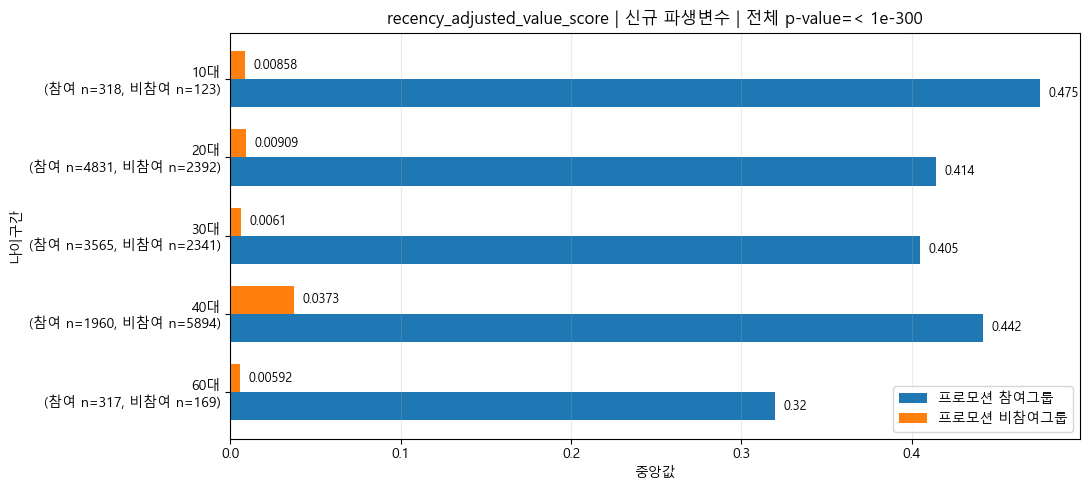

,age_group,p_value_표기,promo_n,nonpromo_n,promo_nonzero_ratio,nonpromo_nonzero_ratio,promo_mean,nonpromo_mean,promo_median,nonpromo_median
0,10대,1.037e-20,318,123,0.943396,0.951220,1.248549,1.686241,0.475000,0.008582
1,20대,8.968e-231,4831,2392,0.937487,0.942726,1.345103,2.891769,0.414286,0.009091
2,30대,< 1e-300,3565,2341,0.934923,0.940196,1.398113,1.685201,0.404615,0.006101
3,40대,3.367e-23,1960,5894,0.944898,0.936037,1.349374,5.813754,0.441984,0.037295
4,60대,4.173e-33,317,169,0.914826,0.923077,1.211271,0.472707,0.320000,0.005917


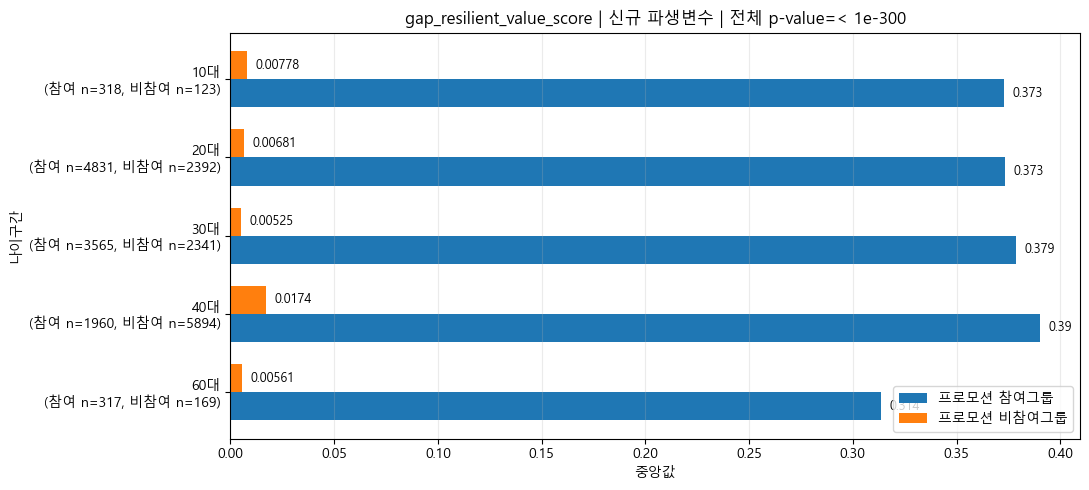

,age_group,p_value_표기,promo_n,nonpromo_n,promo_nonzero_ratio,nonpromo_nonzero_ratio,promo_mean,nonpromo_mean,promo_median,nonpromo_median
0,10대,2.808e-23,318,123,0.943396,0.951220,0.602626,0.847898,0.372667,0.007785
1,20대,1.371e-252,4831,2392,0.937487,0.942726,0.606900,1.292155,0.373333,0.006813
2,30대,< 1e-300,3565,2341,0.934923,0.940196,0.599863,0.797011,0.378750,0.005253
3,40대,5.286e-15,1960,5894,0.944898,0.936037,0.622376,2.784349,0.390000,0.017381
4,60대,2.017e-37,317,169,0.914826,0.923077,0.560040,0.296649,0.313636,0.005612


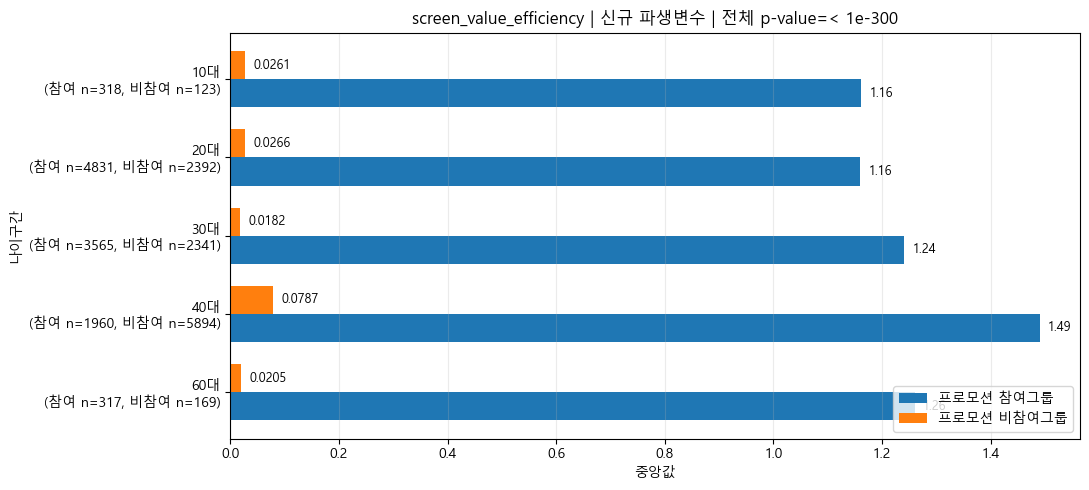

,age_group,p_value_표기,promo_n,nonpromo_n,promo_nonzero_ratio,nonpromo_nonzero_ratio,promo_mean,nonpromo_mean,promo_median,nonpromo_median
0,10대,1.078e-20,318,123,0.943396,0.951220,2.119992,4.052298,1.16125,0.026076
1,20대,1.625e-221,4831,2392,0.937487,0.942726,2.161921,5.436103,1.16000,0.026582
2,30대,< 1e-300,3565,2341,0.934923,0.940196,2.243478,3.529963,1.24000,0.018228
3,40대,3.460e-12,1960,5894,0.944898,0.936037,2.417645,12.049366,1.49000,0.078734
4,60대,3.197e-34,317,169,0.914826,0.923077,2.119377,1.280504,1.26000,0.020506


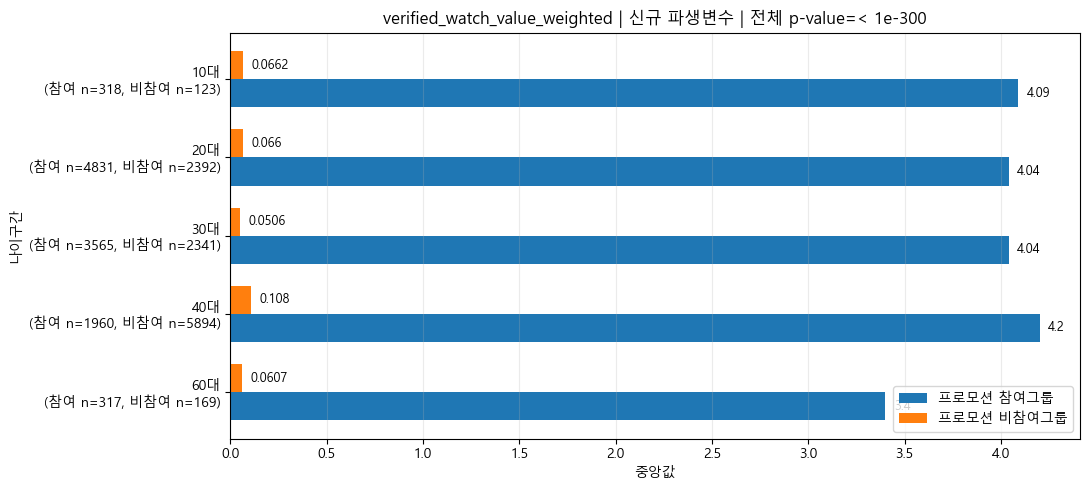

,age_group,p_value_표기,promo_n,nonpromo_n,promo_nonzero_ratio,nonpromo_nonzero_ratio,promo_mean,nonpromo_mean,promo_median,nonpromo_median
0,10대,6.286e-22,318,123,0.943396,0.951220,5.839748,8.720260,4.09,0.066187
1,20대,2.985e-232,4831,2392,0.937487,0.942726,5.935831,11.720322,4.04,0.065974
2,30대,< 1e-300,3565,2341,0.934923,0.940196,5.917004,7.944019,4.04,0.050642
3,40대,1.214e-27,1960,5894,0.944898,0.936037,6.007908,14.081328,4.20,0.108038
4,60대,1.184e-35,317,169,0.914826,0.923077,5.539432,2.568411,3.40,0.060719


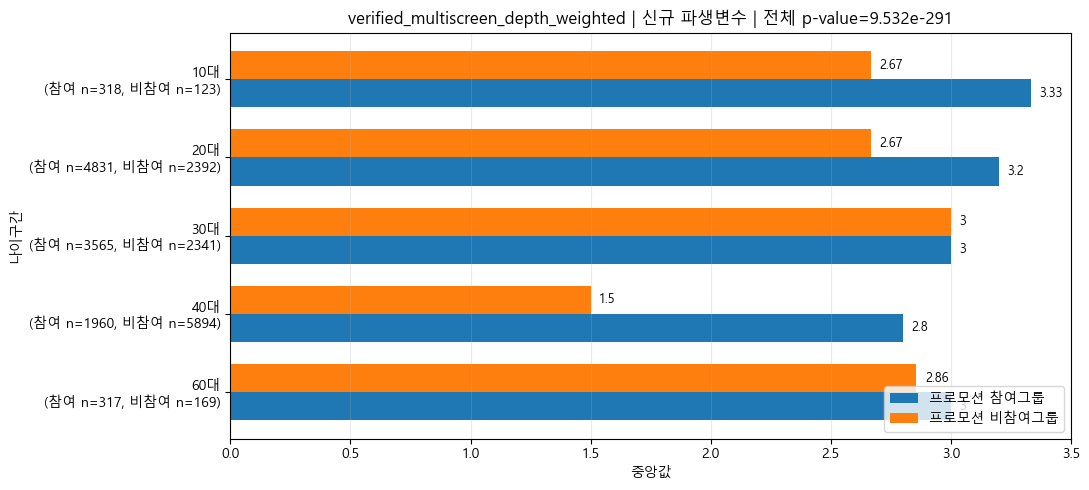

,age_group,p_value_표기,promo_n,nonpromo_n,promo_nonzero_ratio,nonpromo_nonzero_ratio,promo_mean,nonpromo_mean,promo_median,nonpromo_median
0,10대,7.834e-03,318,123,0.943396,0.951220,5.207908,3.878859,3.333333,2.666667
1,20대,8.346e-20,4831,2392,0.937487,0.942726,4.992586,3.812830,3.200000,2.666667
2,30대,2.046e-04,3565,2341,0.934923,0.940196,4.613388,4.015289,3.000000,3.000000
3,40대,2.575e-169,1960,5894,0.944898,0.936037,4.241609,2.266045,2.800000,1.500000
4,60대,1.119e-01,317,169,0.914826,0.923077,4.443793,3.457942,3.000000,2.857143


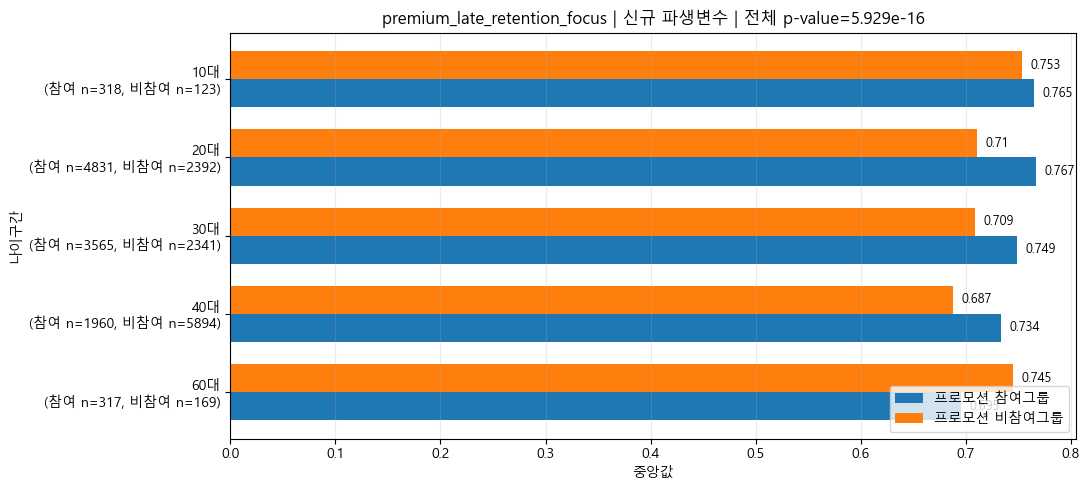

,age_group,p_value_표기,promo_n,nonpromo_n,promo_nonzero_ratio,nonpromo_nonzero_ratio,promo_mean,nonpromo_mean,promo_median,nonpromo_median
0,10대,6.873e-01,318,123,0.827044,0.837398,0.782944,0.743100,0.765036,0.753316
1,20대,2.174e-07,4831,2392,0.842890,0.837375,0.757095,0.664384,0.766816,0.710477
2,30대,1.001e-02,3565,2341,0.836185,0.839812,0.711496,0.665015,0.749141,0.708995
3,40대,9.878e-04,1960,5894,0.847449,0.836953,0.695532,0.643221,0.733599,0.687412
4,60대,9.707e-01,317,169,0.823344,0.857988,0.688391,0.646670,0.695122,0.744912


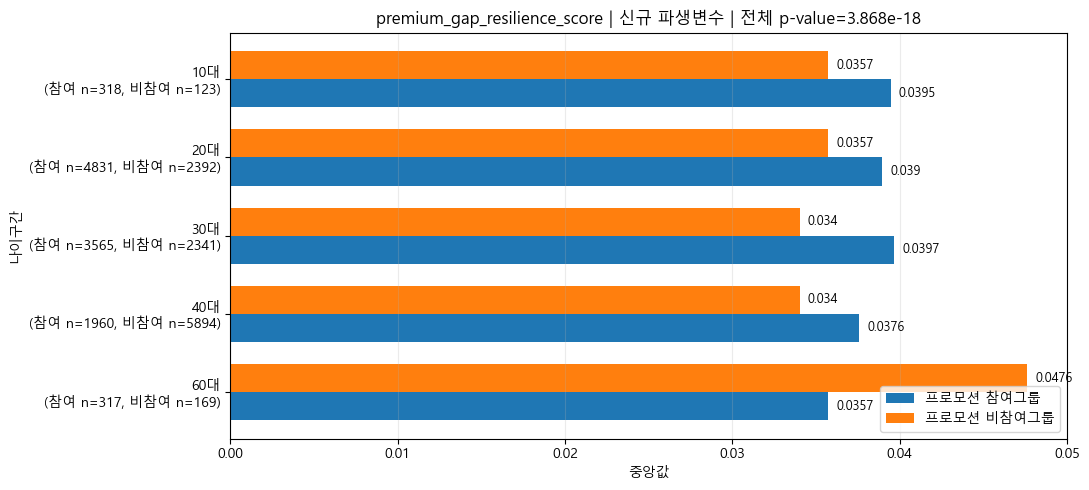

,age_group,p_value_표기,promo_n,nonpromo_n,promo_nonzero_ratio,nonpromo_nonzero_ratio,promo_mean,nonpromo_mean,promo_median,nonpromo_median
0,10대,4.859e-01,318,123,0.943396,0.951220,0.046017,0.041834,0.039456,0.035714
1,20대,1.857e-06,4831,2392,0.937487,0.942726,0.044615,0.039111,0.038961,0.035714
2,30대,4.666e-04,3565,2341,0.934923,0.940196,0.042529,0.039375,0.039683,0.034014
3,40대,4.665e-05,1960,5894,0.944898,0.936037,0.041456,0.038024,0.037566,0.034014
4,60대,2.993e-01,317,169,0.914826,0.923077,0.041347,0.044229,0.035714,0.047619


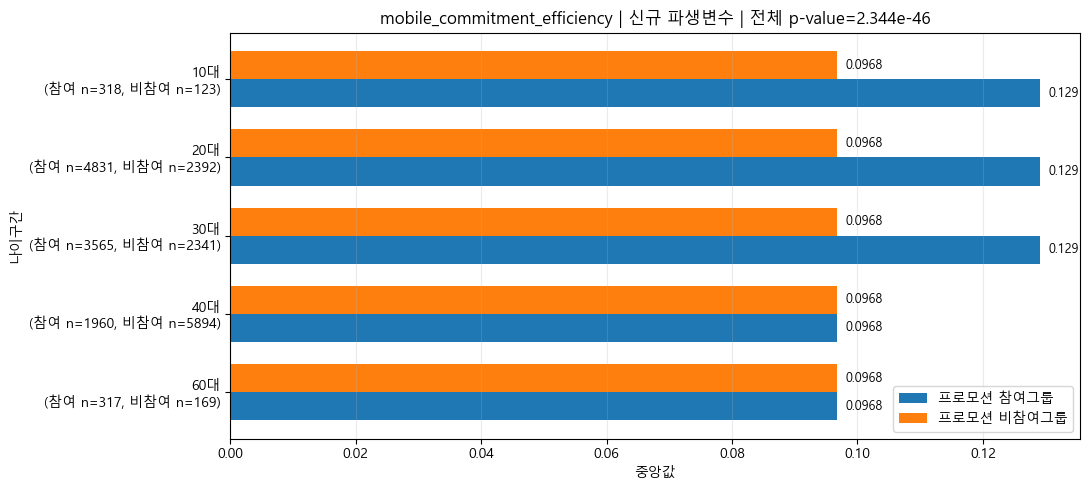

,age_group,p_value_표기,promo_n,nonpromo_n,promo_nonzero_ratio,nonpromo_nonzero_ratio,promo_mean,nonpromo_mean,promo_median,nonpromo_median
0,10대,1.424e-01,318,123,0.943396,0.934959,0.140292,0.125549,0.129032,0.096774
1,20대,1.430e-14,4831,2392,0.937280,0.939799,0.150207,0.137000,0.129032,0.096774
2,30대,8.994e-06,3565,2341,0.932959,0.937206,0.143376,0.154136,0.129032,0.096774
3,40대,2.634e-11,1960,5894,0.940306,0.929589,0.138797,0.136806,0.096774,0.096774
4,60대,9.258e-01,317,169,0.914826,0.917160,0.130050,0.724804,0.096774,0.096774


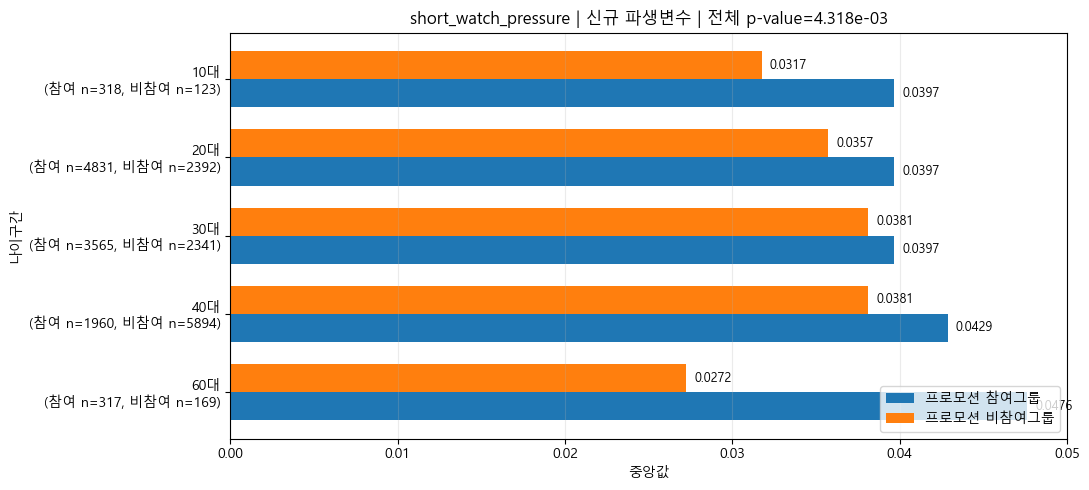

,age_group,p_value_표기,promo_n,nonpromo_n,promo_nonzero_ratio,nonpromo_nonzero_ratio,promo_mean,nonpromo_mean,promo_median,nonpromo_median
0,10대,5.766e-01,318,123,0.679245,0.691057,0.045937,0.041472,0.039683,0.031746
1,20대,1.083e-02,4831,2392,0.684330,0.657191,0.049796,0.046951,0.039683,0.035714
2,30대,4.895e-01,3565,2341,0.676858,0.689876,0.051278,0.049258,0.039683,0.038095
3,40대,8.362e-02,1960,5894,0.695918,0.680183,0.051637,0.049627,0.042857,0.038095
4,60대,1.948e-04,317,169,0.700315,0.609467,0.058293,0.039535,0.047619,0.027211


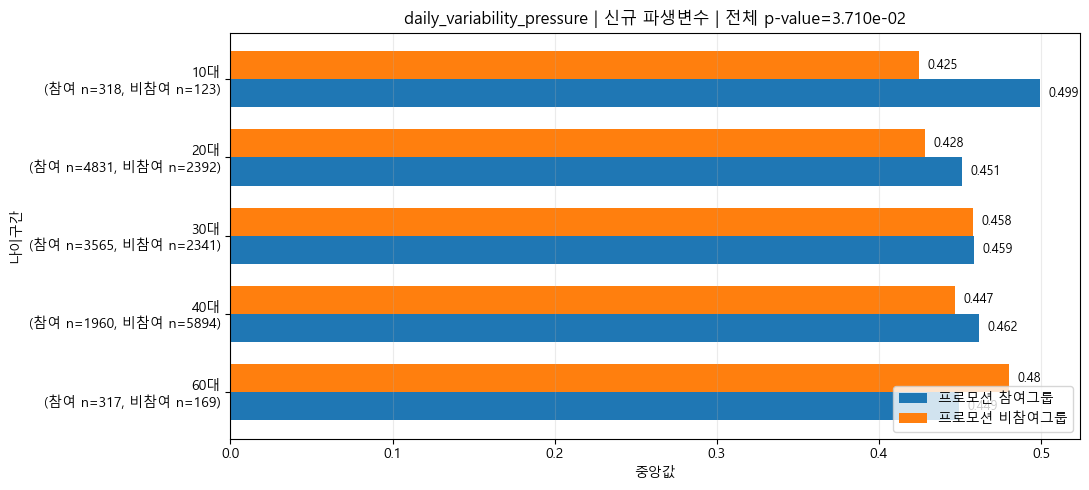

,age_group,p_value_표기,promo_n,nonpromo_n,promo_nonzero_ratio,nonpromo_nonzero_ratio,promo_mean,nonpromo_mean,promo_median,nonpromo_median
0,10대,4.047e-01,318,123,0.833333,0.853659,0.485002,0.462835,0.499035,0.424563
1,20대,5.307e-02,4831,2392,0.819085,0.810619,0.462696,0.445036,0.451248,0.428201
2,30대,7.359e-01,3565,2341,0.809257,0.824434,0.460275,0.461860,0.458599,0.457904
3,40대,4.650e-02,1960,5894,0.819388,0.811334,0.475902,0.454934,0.461590,0.446881
4,60대,4.837e-01,317,169,0.804416,0.810651,0.468843,0.448667,0.449150,0.480001


In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import mannwhitneyu

# 한글 표시 설정값 정의
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 색상 설정값 정의
promo_color = "#1f77b4"
nonpromo_color = "#ff7f0e"
bar_height = 0.36

# 신규 파생변수 목록 정의
new_derived_features = [
    "recency_adjusted_value_score",
    "gap_resilient_value_score",
    "screen_value_efficiency",
    "verified_watch_value_weighted",
    "verified_multiscreen_depth_weighted",
    "premium_late_retention_focus",
    "premium_gap_resilience_score",
    "mobile_commitment_efficiency",
    "short_watch_pressure",
    "daily_variability_pressure",
]

# 실행 전 변수 확인값 정의
required_variables = ["membership"]

missing_variables = [
    var_name for var_name in required_variables
    if var_name not in globals()
]

if missing_variables:
    raise ValueError(
        f"먼저 실행 필요한 변수 존재: {', '.join(missing_variables)}"
    )

missing_features = [
    feature_name for feature_name in new_derived_features
    if feature_name not in membership.columns
]

if missing_features:
    raise ValueError(
        f"membership에 없는 신규 파생변수 존재: {', '.join(missing_features)}"
    )

# 나이대 순서 정의
default_age_group_order = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]

if "significant_age_groups" in globals() and len(significant_age_groups) > 0:
    age_group_order = [
        age_group for age_group in default_age_group_order
        if age_group in set(map(str, significant_age_groups))
    ]
else:
    age_group_order = [
        age_group for age_group in default_age_group_order
        if age_group in set(membership["age_group"].astype(str).unique())
    ]

# 시각화 대상 데이터 준비
plot_df = membership[
    membership["age_group"].astype(str).isin(age_group_order)
].copy()

# p-value 문자열 포맷 함수 정의
def format_pvalue_text(pvalue):
    if pd.isna(pvalue):
        return "NA"

    if pvalue < 1e-300:
        return "< 1e-300"

    return f"{pvalue:.3e}"

# 나이대별 표본 수 라벨 생성 함수 정의
def build_age_group_labels_with_n(df, age_group_order):
    labels = []

    for age_group in age_group_order:
        age_df = df[df["age_group"].astype(str) == age_group].copy()

        promo_n = int((age_df["is_promotion"] == 1).sum())
        nonpromo_n = int((age_df["is_promotion"] == 0).sum())

        labels.append(
            f"{age_group}\n(참여 n={promo_n}, 비참여 n={nonpromo_n})"
        )

    return labels

# 수치형 막대 라벨 함수 정의
def add_bar_labels(ax, bars):
    x_right = ax.get_xlim()[1]
    x_offset = x_right * 0.01 if x_right != 0 else 0.01

    for bar in bars:
        width = bar.get_width()

        if pd.isna(width):
            continue

        y_pos = bar.get_y() + bar.get_height() / 2

        ax.text(
            width + x_offset,
            y_pos,
            f"{width:.3g}",
            va="center",
            ha="left",
            fontsize=9
        )

# 전체 p-value 계산 함수 정의
def get_overall_pvalue(df, feature_name):
    promo_values = pd.to_numeric(
        df.loc[df["is_promotion"] == 1, feature_name],
        errors="coerce"
    ).dropna()

    nonpromo_values = pd.to_numeric(
        df.loc[df["is_promotion"] == 0, feature_name],
        errors="coerce"
    ).dropna()

    if len(promo_values) == 0 or len(nonpromo_values) == 0:
        return np.nan

    return mannwhitneyu(
        nonpromo_values,
        promo_values,
        alternative="two-sided",
        method="auto"
    ).pvalue

# 나이대별 요약 테이블 생성 함수 정의
def build_new_feature_summary(df, feature_name, age_group_order):
    rows = []

    for age_group in age_group_order:
        age_df = df[df["age_group"].astype(str) == age_group].copy()

        promo_values = pd.to_numeric(
            age_df.loc[age_df["is_promotion"] == 1, feature_name],
            errors="coerce"
        ).dropna()

        nonpromo_values = pd.to_numeric(
            age_df.loc[age_df["is_promotion"] == 0, feature_name],
            errors="coerce"
        ).dropna()

        if len(promo_values) == 0 or len(nonpromo_values) == 0:
            pvalue = np.nan
        else:
            pvalue = mannwhitneyu(
                nonpromo_values,
                promo_values,
                alternative="two-sided",
                method="auto"
            ).pvalue

        rows.append(
            {
                "age_group": age_group,
                "promo_n": len(promo_values),
                "nonpromo_n": len(nonpromo_values),
                "promo_median": promo_values.median() if len(promo_values) > 0 else np.nan,
                "nonpromo_median": nonpromo_values.median() if len(nonpromo_values) > 0 else np.nan,
                "promo_mean": promo_values.mean() if len(promo_values) > 0 else np.nan,
                "nonpromo_mean": nonpromo_values.mean() if len(nonpromo_values) > 0 else np.nan,
                "promo_nonzero_ratio": (promo_values != 0).mean() if len(promo_values) > 0 else np.nan,
                "nonpromo_nonzero_ratio": (nonpromo_values != 0).mean() if len(nonpromo_values) > 0 else np.nan,
                "pvalue": pvalue,
            }
        )

    summary_df = pd.DataFrame(rows)

    return summary_df

# 수치형 그래프 함수 정의
def plot_new_numeric_feature(df, feature_name, age_group_order):
    summary_df = build_new_feature_summary(
        df=df,
        feature_name=feature_name,
        age_group_order=age_group_order
    )

    overall_pvalue = get_overall_pvalue(df, feature_name)

    age_group_labels = build_age_group_labels_with_n(df, age_group_order)
    y = np.arange(len(summary_df))

    fig, ax = plt.subplots(figsize=(11, max(4.8, len(summary_df) * 1.0)))

    promo_bars = ax.barh(
        y + bar_height / 2,
        summary_df["promo_median"],
        height=bar_height,
        color=promo_color,
        label="프로모션 참여그룹"
    )

    nonpromo_bars = ax.barh(
        y - bar_height / 2,
        summary_df["nonpromo_median"],
        height=bar_height,
        color=nonpromo_color,
        label="프로모션 비참여그룹"
    )

    ax.set_yticks(y)
    ax.set_yticklabels(age_group_labels)
    ax.invert_yaxis()
    ax.set_ylabel("나이구간")
    ax.set_xlabel("중앙값")
    ax.set_title(
        f"{feature_name} | 신규 파생변수 | 전체 p-value={format_pvalue_text(overall_pvalue)}"
    )

    ax.grid(axis="x", alpha=0.25)
    ax.legend(loc="lower right")

    add_bar_labels(ax, promo_bars)
    add_bar_labels(ax, nonpromo_bars)

    plt.tight_layout()
    plt.show()

    display_table = summary_df.copy()
    display_table["p_value_표기"] = display_table["pvalue"].apply(format_pvalue_text)
    display_table = display_table[
        [
            "age_group",
            "p_value_표기",
            "promo_n",
            "nonpromo_n",
            "promo_nonzero_ratio",
            "nonpromo_nonzero_ratio",
            "promo_mean",
            "nonpromo_mean",
            "promo_median",
            "nonpromo_median",
        ]
    ]

    display(display_table)

# 신규 파생변수별 그래프 출력
for feature_name in new_derived_features:
    plot_new_numeric_feature(
        df=plot_df,
        feature_name=feature_name,
        age_group_order=age_group_order
    )
    print()